# 🧠 CreditRiskAI — Day 3: Machine Learning Modeling, Asymmetric Risk Optimization & Explainable AI (SHAP)
**Project**: Give Me Some Credit (Retail Delinquency Prediction)  
**Author**: Ganendra Pradipa | [Portfolio](https://ganendra.space) | [LinkedIn](https://www.linkedin.com/in/ganendrapratama) | [GitHub](https://github.com/dipndeep)  
**Objective**: Build a production-grade credit scoring engine across 150,000 borrower profiles, benchmark traditional Basel II Scorecards against gradient boosting, optimize asymmetric financial risk cutoffs, and provide transparent regulatory explanations via SHAP (XAI).

---

## 📌 Executive Overview: Beyond the "93% Accuracy Trap"

In retail banking, a default rate of **6.68%** means a naive model predicting *"No Default"* achieves **93.32% accuracy** while losing millions in defaulted principal. 

In this notebook, we execute **Phase 3** of our credit risk framework:
1. **Benchmark Modeling**: Logistic Regression (*traditional scorecard standard*) vs Random Forest & tuned XGBoost (*non-linear challenger* with `scale_pos_weight`).
2. **Financial Risk Metrics**: Rigorous evaluation using **ROC-AUC, PR-AUC, Gini Coefficient, and the Kolmogorov-Smirnov (KS) Statistic**.
3. **Asymmetric Loss Optimization**: Calibrating decision thresholds against real-world loss costs ($C_{FN} = \$10{,}000$ vs $C_{FP} = \$1{,}000$).
4. **Explainable AI (SHAP)**: Global portfolio risk driver attribution and individual customer **Adverse Action Notice** generation for Fair Lending regulatory compliance.
5. **Production Model Serialization**: Saving the final scoring engine to `models/` for our Day 4 interactive risk simulator.


In [1]:
import os
import json
import time
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp
from IPython.display import display

# Scikit-learn & Modeling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score, brier_score_loss, confusion_matrix
)
from xgboost import XGBClassifier
import shap

# Professional Banking & Corporate Aesthetics
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

# Fintech Corporate Color Palette
NAVY_PRIMARY = '#0f172a'
BLUE_SCORECARD = '#1e3a8a'
CYAN_CHALLENGER = '#0284c7'
RED_ALERT = '#ef4444'
GREEN_APPROVAL = '#10b981'
AMBER_WARNING = '#f59e0b'

print("Libraries imported successfully. System ready for Day 3 Machine Learning.")


Libraries imported successfully. System ready for Day 3 Machine Learning.


---
## 1. 📂 Data Loading & Stratified Partitioning (Anti-Data Leakage)

We load the sanitized dataset `data/processed/train_cleaned.csv` (150,000 records × 16 columns) produced by our Day 1 pipeline.
To maintain the exact **6.68% default rate** across splits and prevent target distribution shifts, we execute a **Stratified 80:20 Train-Test Split**:
* **Training Set**: 120,000 borrowers (strictly used for model learning and feature scaling)
* **Holdout Validation Set**: 30,000 borrowers (strictly reserved for out-of-sample risk evaluation)


In [2]:
# Load Cleaned Dataset
df = pd.read_csv('../data/processed/train_cleaned.csv')

TARGET = 'SeriousDlqin2yrs'
FEATURES = [c for c in df.columns if c != TARGET]

X = df[FEATURES]
y = df[TARGET]

# Stratified Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Total Portfolio: {len(df):,} borrowers")
print(f"Training Set   : {len(X_train):,} records | Default Rate: {y_train.mean():.4%}")
print(f"Holdout Test   : {len(X_test):,} records | Default Rate: {y_test.mean():.4%}")
print(f"Predictors ({len(FEATURES)} features): {FEATURES}")


Total Portfolio: 150,000 borrowers
Training Set   : 120,000 records | Default Rate: 6.6842%
Holdout Test   : 30,000 records | Default Rate: 6.6833%
Predictors (15 features): ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents', 'HasPastDueRecordError', 'RevolvingUtilizationOverLimit', 'MonthlyIncome_is_missing', 'DebtRatio_is_extreme', 'NumberOfDependents_is_missing']


---
## 2. 🏛️ Model 1 (Baseline Scorecard): Logistic Regression

In traditional consumer credit underwriting (e.g. FICO scorecards & Basel II IRB frameworks), **Logistic Regression** remains the golden benchmark due to its strict interpretability and linear log-odds mapping:
$$\ln\left(\frac{P}{1-P}\right) = \beta_0 + \sum_{i=1}^k \beta_i X_i$$

### Preprocessing & Class Balance:
* **StandardScaler**: Fitted strictly on $X_{train}$ and applied to $X_{test}$ to prevent data leakage.
* **Class Weighting**: Set to `'balanced'` to inversely weight instances by class frequencies:
  $$w_1 = \frac{N}{2 \times N_1} \approx 7.49, \quad w_0 = \frac{N}{2 \times N_0} \approx 0.54$$


In [3]:
# Scale features for linear estimator
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Baseline Logistic Regression
t0 = time.time()
lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)
lr_time = time.time() - t0

# Predict probabilities on holdout test set
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

# Display Coefficients & Odds Ratios
coeff_df = pd.DataFrame({
    'Feature': FEATURES,
    'Coefficient (Beta)': lr_model.coef_[0],
    'Odds Ratio (exp(Beta))': np.exp(lr_model.coef_[0])
}).sort_values(by='Coefficient (Beta)', ascending=False).reset_index(drop=True)

print(f"Logistic Regression trained in {lr_time:.2f}s")
print(f"Holdout ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.4f}")
coeff_df.head(8)


Logistic Regression trained in 0.14s
Holdout ROC-AUC: 0.8614


,Feature,Coefficient (Beta),Odds Ratio (exp(Beta))
0,RevolvingUtilizationOfUnsecuredLines,0.716003,2.046238
1,NumberOfTimes90DaysLate,0.497344,1.644348
2,NumberOfTime30-59DaysPastDueNotWorse,0.398156,1.489077
3,NumberOfTime60-89DaysPastDueNotWorse,0.318094,1.374506
4,NumberOfOpenCreditLinesAndLoans,0.175224,1.191513
5,NumberRealEstateLoansOrLines,0.147992,1.159503
6,HasPastDueRecordError,0.106735,1.112639
7,DebtRatio_is_extreme,0.046755,1.047865


---
## 3. 🌲 Non-Linear Challengers: Random Forest & Tuned XGBoost

While linear scorecards offer transparency, they fail to model high-order interaction effects or non-linear tipping points (e.g., the sharp 70% credit utilization inflection uncovered on Day 2).

We deploy two advanced ensemble architectures:
1. **Model 2: Random Forest Classifier**:
   - `n_estimators=100`, `max_depth=10`, `class_weight='balanced_subsample'`
   - Averages decorrelated decision trees to dampen variance and resist overfitting.
2. **Model 3: Tuned XGBoost Classifier**:
   - Gradient boosted trees optimizing the binary logistic objective.
   - `scale_pos_weight = (N_neg / N_pos) ≈ 13.97` to directly penalize missed defaults during gradient descent.
   - Constrained tree depth (`max_depth=5`) and conservative learning rate (`learning_rate=0.05`) to prevent overfitting.


In [4]:
# Calculate exact class imbalance ratio for XGBoost
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight_value = neg_count / pos_count
print(f"Class Imbalance Ratio (scale_pos_weight): {scale_pos_weight_value:.2f}")

# Model 2: Random Forest
t0 = time.time()
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=20,
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
rf_time = time.time() - t0
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]
print(f"Random Forest trained in {rf_time:.2f}s | ROC-AUC: {roc_auc_score(y_test, y_prob_rf):.4f}")

# Model 3: XGBoost Classifier
t0 = time.time()
xgb_model = XGBClassifier(
    n_estimators=120,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight_value,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='auc',
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)
xgb_time = time.time() - t0
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]
print(f"XGBoost Classifier trained in {xgb_time:.2f}s | ROC-AUC: {roc_auc_score(y_test, y_prob_xgb):.4f}")


Class Imbalance Ratio (scale_pos_weight): 13.96


Random Forest trained in 2.76s | ROC-AUC: 0.8657


XGBoost Classifier trained in 2.08s | ROC-AUC: 0.8686


---
## 4. 📊 Head-to-Head Model Evaluation: ROC-AUC, PR-AUC & Brier Score

In asymmetric lending distributions:
* **ROC-AUC**: Measures discriminatory capability across all potential decision thresholds.
* **Gini Coefficient**: $2 \times \text{AUC} - 1$, standard reporting metric for bank credit committees.
* **PR-AUC (Precision-Recall AUC)**: Highly sensitive to the minority class (6.68%), exposing true positive predictive value without dilution by true negatives.
* **Brier Score**: Measures probability calibration (mean squared error of probability forecasts; lower is better).


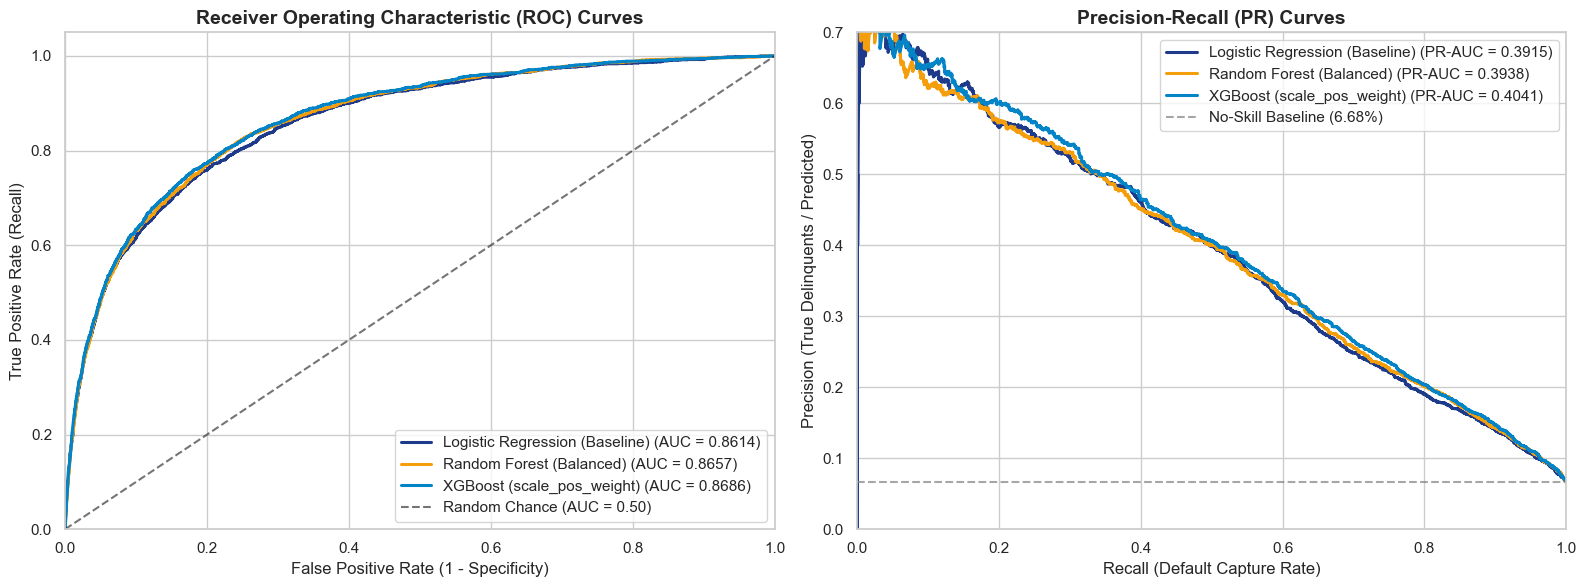

,Model Architecture,ROC-AUC,PR-AUC,Gini Coefficient,Brier Score
0,Logistic Regression (Baseline),0.8614,0.3915,0.7227,0.1439
1,Random Forest (Balanced),0.8657,0.3938,0.7314,0.1370
2,XGBoost (scale_pos_weight),0.8686,0.4041,0.7372,0.1416


In [5]:
# Compute comprehensive metrics
models_dict = {
    'Logistic Regression (Baseline)': y_prob_lr,
    'Random Forest (Balanced)': y_prob_rf,
    'XGBoost (scale_pos_weight)': y_prob_xgb
}

results_list = []
for name, probs in models_dict.items():
    auc_val = roc_auc_score(y_test, probs)
    pr_auc_val = average_precision_score(y_test, probs)
    gini_val = 2 * auc_val - 1
    brier_val = brier_score_loss(y_test, probs)
    results_list.append({
        'Model Architecture': name,
        'ROC-AUC': round(auc_val, 4),
        'PR-AUC': round(pr_auc_val, 4),
        'Gini Coefficient': round(gini_val, 4),
        'Brier Score': round(brier_val, 4)
    })

comparison_df = pd.DataFrame(results_list)

# Generate Side-by-Side ROC & PR Curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

colors = [BLUE_SCORECARD, AMBER_WARNING, CYAN_CHALLENGER]

# Plot ROC Curves
for (name, probs), col in zip(models_dict.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc_score = roc_auc_score(y_test, probs)
    ax1.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.4f})", color=col, lw=2.2)

ax1.plot([0, 1], [0, 1], 'k--', alpha=0.6, label='Random Chance (AUC = 0.50)')
ax1.set_title('Receiver Operating Characteristic (ROC) Curves', fontweight='bold', fontsize=14)
ax1.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
ax1.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax1.legend(loc='lower right', frameon=True)
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])

# Plot Precision-Recall Curves
baseline_pr = y_test.mean()
for (name, probs), col in zip(models_dict.items(), colors):
    prec, rec, _ = precision_recall_curve(y_test, probs)
    pr_auc = average_precision_score(y_test, probs)
    ax2.plot(rec, prec, label=f"{name} (PR-AUC = {pr_auc:.4f})", color=col, lw=2.2)

ax2.axhline(baseline_pr, color='gray', linestyle='--', alpha=0.7, label=f'No-Skill Baseline ({baseline_pr:.2%})')
ax2.set_title('Precision-Recall (PR) Curves', fontweight='bold', fontsize=14)
ax2.set_xlabel('Recall (Default Capture Rate)', fontsize=12)
ax2.set_ylabel('Precision (True Delinquents / Predicted)', fontsize=12)
ax2.legend(loc='upper right', frameon=True)
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 0.7])

plt.tight_layout()
plt.show()

display(comparison_df)


---
## 5. 🎯 Credit Risk Analytics: KS-Statistic & Decile Lift Analysis

Under international risk management standards (Basel II / FICO):
* **Kolmogorov-Smirnov (KS) Statistic**: Measures the maximum vertical separation between the cumulative distribution functions of Goods (non-defaulting) and Bads (defaulting borrowers).
  $$\text{KS} = \max |F_{\text{Bad}}(s) - F_{\text{Good}}(s)|$$
  * A KS statistic **> 40%** indicates an excellent, highly discriminative credit risk scoring model.
* **Decile Lift Analysis**: Confirms whether default risk is concentrated in the top 10%–20% highest-risk scoring tiers.


KOLMOGOROV-SMIRNOV (KS) BENCHMARKING:
• Logistic Regression (Baseline)  : KS = 56.39%
• Random Forest (Balanced)        : KS = 57.57%
• XGBoost (scale_pos_weight)      : KS = 57.84%
Champion Model Max KS: 57.84% at Probability Cutoff 0.5302


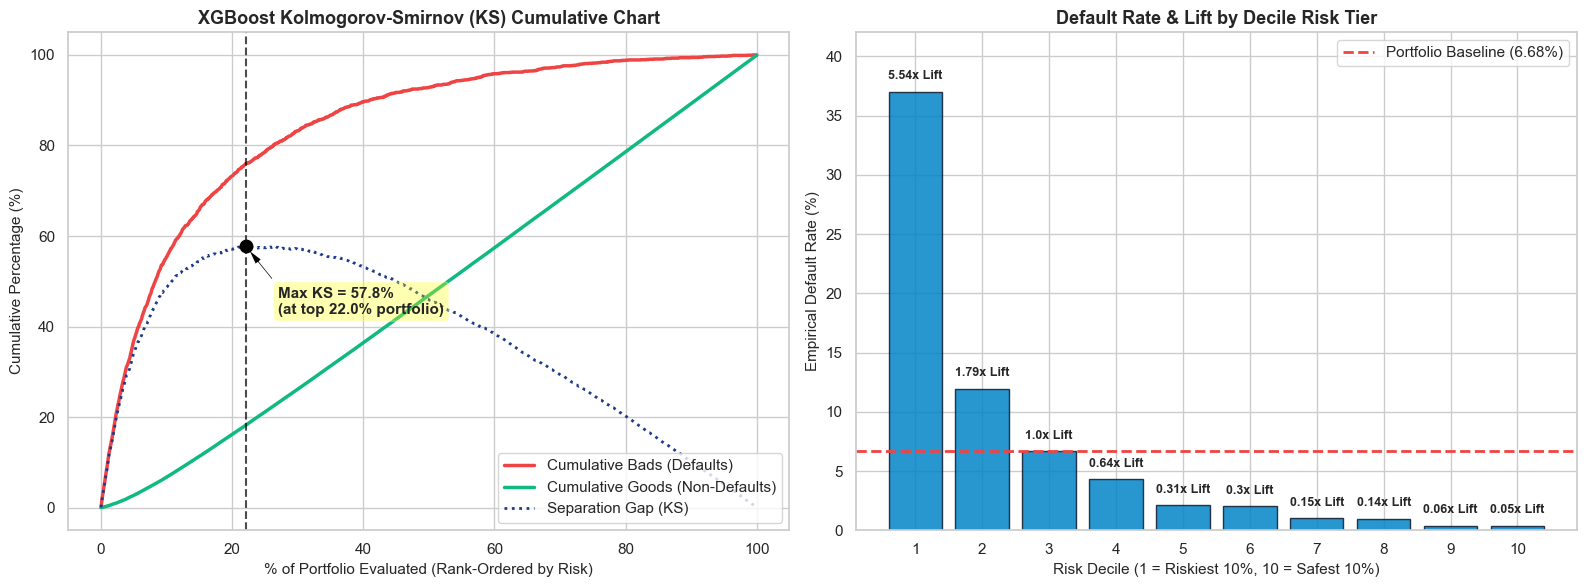

,decile,Borrowers,Defaults,Default_Rate_%,Cum_Capture_Rate_%,Lift_Multiplier
0,1,3000,1111,37.03,55.41,5.54
1,2,3000,358,11.93,73.27,1.79
2,3,3000,200,6.67,83.24,1.00
3,4,3000,129,4.30,89.68,0.64
4,5,3000,63,2.10,92.82,0.31
5,6,3000,61,2.03,95.86,0.30
6,7,3000,31,1.03,97.41,0.15
7,8,3000,29,0.97,98.85,0.14
8,9,3000,12,0.40,99.45,0.06
9,10,3000,11,0.37,100.00,0.05


In [6]:
# Compute Kolmogorov-Smirnov (KS) Statistic for all models
ks_results = {}
for name, probs in models_dict.items():
    goods = probs[y_test == 0]
    bads = probs[y_test == 1]
    stat, p_val = ks_2samp(bads, goods)
    ks_results[name] = stat

# Detailed KS Curve & Decile Analysis for Champion Model (XGBoost)
df_eval = pd.DataFrame({
    'actual': y_test.values,
    'pred_prob': y_prob_xgb
}).sort_values(by='pred_prob', ascending=False).reset_index(drop=True)

df_eval['good'] = 1 - df_eval['actual']
df_eval['cum_bads'] = df_eval['actual'].cumsum() / df_eval['actual'].sum()
df_eval['cum_goods'] = df_eval['good'].cumsum() / df_eval['good'].sum()
df_eval['ks_gap'] = np.abs(df_eval['cum_bads'] - df_eval['cum_goods'])

max_ks_idx = df_eval['ks_gap'].idxmax()
max_ks_val = df_eval.loc[max_ks_idx, 'ks_gap']
max_ks_prob = df_eval.loc[max_ks_idx, 'pred_prob']
pop_pct_at_ks = (max_ks_idx + 1) / len(df_eval) * 100

print(f"==================================================")
print(f"KOLMOGOROV-SMIRNOV (KS) BENCHMARKING:")
for k, v in ks_results.items():
    print(f"• {k:<32}: KS = {v*100:.2f}%")
print(f"Champion Model Max KS: {max_ks_val*100:.2f}% at Probability Cutoff {max_ks_prob:.4f}")
print(f"==================================================")

# Generate Decile Lift Table
df_eval['decile'] = pd.qcut(df_eval['pred_prob'], q=10, labels=False, duplicates='drop')
df_eval['decile'] = 10 - df_eval['decile'] # Decile 1 = Highest Risk

decile_table = df_eval.groupby('decile').agg(
    Borrowers=('actual', 'count'),
    Defaults=('actual', 'sum'),
    Default_Rate=('actual', 'mean')
).reset_index()

baseline_rate = y_test.mean()
decile_table['Cum_Defaults'] = decile_table['Defaults'].cumsum()
decile_table['Cum_Capture_Rate_%'] = (decile_table['Cum_Defaults'] / y_test.sum() * 100).round(2)
decile_table['Lift_Multiplier'] = (decile_table['Default_Rate'] / baseline_rate).round(2)
decile_table['Default_Rate_%'] = (decile_table['Default_Rate'] * 100).round(2)

# Visualizing KS Separation & Decile Lift
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# KS Curve
eval_sample = df_eval.iloc[::20] # Downsample for smooth plotting
pop_percentiles = np.linspace(0, 100, len(eval_sample))
ax1.plot(pop_percentiles, eval_sample['cum_bads'] * 100, color=RED_ALERT, lw=2.5, label='Cumulative Bads (Defaults)')
ax1.plot(pop_percentiles, eval_sample['cum_goods'] * 100, color=GREEN_APPROVAL, lw=2.5, label='Cumulative Goods (Non-Defaults)')
ax1.plot(pop_percentiles, eval_sample['ks_gap'] * 100, color=BLUE_SCORECARD, linestyle=':', lw=2, label='Separation Gap (KS)')
ax1.axvline(pop_pct_at_ks, color='black', linestyle='--', alpha=0.7)
ax1.scatter([pop_pct_at_ks], [max_ks_val * 100], color='black', s=80, zorder=5)

ks_annotation_text = f"Max KS = {max_ks_val*100:.1f}%\n(at top {pop_pct_at_ks:.1f}% portfolio)"
ax1.annotate(ks_annotation_text,
             xy=(pop_pct_at_ks, max_ks_val * 100), xytext=(pop_pct_at_ks + 5, max_ks_val * 100 - 15),
             arrowprops=dict(facecolor='black', shrink=0.08, width=1.5, headwidth=6),
             fontweight='bold', bbox=dict(boxstyle='round,pad=0.3', fc='yellow', alpha=0.3))
ax1.set_title('XGBoost Kolmogorov-Smirnov (KS) Cumulative Chart', fontweight='bold', fontsize=13)
ax1.set_xlabel('% of Portfolio Evaluated (Rank-Ordered by Risk)', fontsize=11)
ax1.set_ylabel('Cumulative Percentage (%)', fontsize=11)
ax1.legend(loc='lower right', frameon=True)

# Decile Lift Bar Chart
bars = ax2.bar(decile_table['decile'], decile_table['Default_Rate_%'], color=CYAN_CHALLENGER, edgecolor=NAVY_PRIMARY, alpha=0.85)
ax2.axhline(baseline_rate * 100, color=RED_ALERT, linestyle='--', lw=2, label=f"Portfolio Baseline ({baseline_rate:.2%})")
for bar, lift in zip(bars, decile_table['Lift_Multiplier']):
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2.0, yval + 0.8, f"{lift}x Lift", ha='center', va='bottom', fontsize=9, fontweight='bold')

ax2.set_title('Default Rate & Lift by Decile Risk Tier', fontweight='bold', fontsize=13)
ax2.set_xlabel('Risk Decile (1 = Riskiest 10%, 10 = Safest 10%)', fontsize=11)
ax2.set_ylabel('Empirical Default Rate (%)', fontsize=11)
ax2.set_xticks(decile_table['decile'])
ax2.legend(loc='upper right', frameon=True)
ax2.set_ylim([0, decile_table['Default_Rate_%'].max() + 5])

plt.tight_layout()
plt.show()

display(decile_table[['decile', 'Borrowers', 'Defaults', 'Default_Rate_%', 'Cum_Capture_Rate_%', 'Lift_Multiplier']])


---
## 6. 💰 Asymmetric Loss Matrix & Cost-Sensitive Threshold Optimization

A conventional machine learning model uses a default classification threshold of **$P = 0.50$**, which assumes symmetric misclassification penalties ($C_{FN} = C_{FP}$). 

In consumer credit, the penalty structure is severely asymmetric:
* **False Negative Cost ($C_{FN}$)**: Borrower defaults, bank writes off unpaid principal and incurs legal fees $\rightarrow \mathbf{\$10{,}000}$.
* **False Positive Cost ($C_{FP}$)**: Good borrower rejected, bank forfeits interest margin and customer lifetime value $\rightarrow \mathbf{\$1{,}000}$ (10:1 ratio).

$$\text{Total Expected Loss} = (\text{FN} \times \$10{,}000) + (\text{FP} \times \$1{,}000)$$

By testing thresholds from $0.05$ to $0.90$, we pinpoint the **economically optimal underwriting cutoff**.


OPTIMAL UNDERWRITING THRESHOLD ANALYSIS:
• Economically Optimal Threshold : 0.56
  - Financial Loss at Optimal    : $9,868,000
  - Defaults Caught (Recall)     : 72.97%
  - Portfolio Approval Rate      : 80.30%
• Standard Naive Threshold (0.50): $10,184,000 (Recall: 77.91%)
• Net Financial Capital Saved    : $316,000 (+3.1% risk reduction)


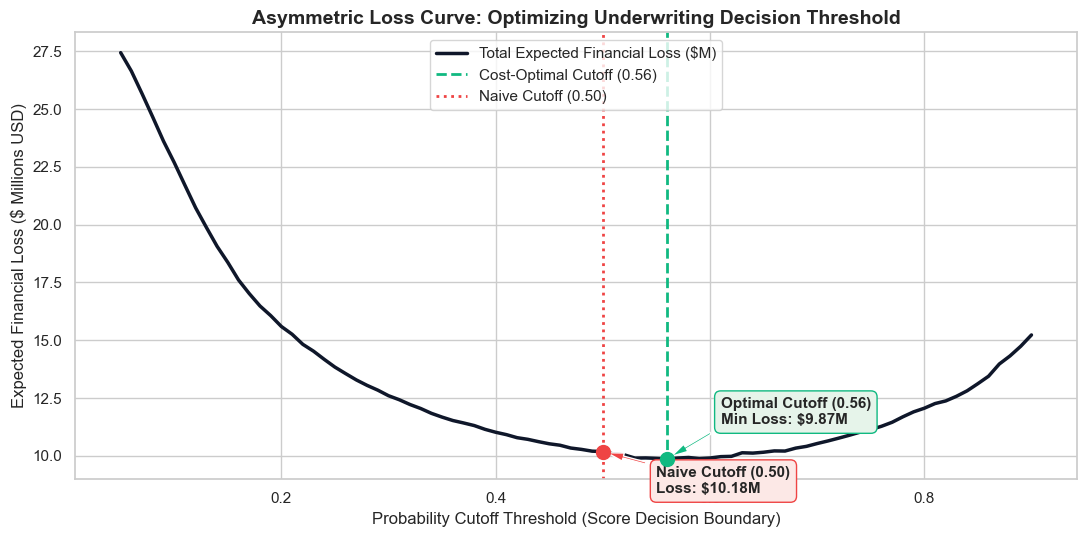

In [7]:
# Financial Cost Parameters
COST_FN = 10000.0  # Direct charge-off per missed defaulted borrower
COST_FP = 1000.0   # Forfeited margin per rejected performing borrower

thresholds = np.linspace(0.05, 0.90, 86)
cost_simulation = []

for th in thresholds:
    y_pred_th = (y_prob_xgb >= th).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_th).ravel()
    
    total_loss = (fn * COST_FN) + (fp * COST_FP)
    approval_rate = (tn + fn) / len(y_test)
    recall = tp / (tp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    
    cost_simulation.append({
        'threshold': th,
        'FN': fn,
        'FP': fp,
        'TP': tp,
        'TN': tn,
        'total_loss': total_loss,
        'approval_rate': approval_rate,
        'recall': recall,
        'precision': precision
    })

sim_df = pd.DataFrame(cost_simulation)

# Find Optimal Cost Threshold vs Naive 0.50 Threshold
optimal_row = sim_df.loc[sim_df['total_loss'].idxmin()]
naive_row = sim_df.loc[(sim_df['threshold'] - 0.50).abs().idxmin()]

savings = naive_row['total_loss'] - optimal_row['total_loss']
savings_pct = (savings / naive_row['total_loss']) * 100

print(f"OPTIMAL UNDERWRITING THRESHOLD ANALYSIS:")
print(f"• Economically Optimal Threshold : {optimal_row['threshold']:.2f}")
print(f"  - Financial Loss at Optimal    : ${optimal_row['total_loss']:,.0f}")
print(f"  - Defaults Caught (Recall)     : {optimal_row['recall']:.2%}")
print(f"  - Portfolio Approval Rate      : {optimal_row['approval_rate']:.2%}")
print(f"• Standard Naive Threshold (0.50): ${naive_row['total_loss']:,.0f} (Recall: {naive_row['recall']:.2%})")
print(f"• Net Financial Capital Saved    : ${savings:,.0f} (+{savings_pct:.1f}% risk reduction)")

# Plot Expected Financial Loss Curve
plt.figure(figsize=(11, 5.5))
plt.plot(sim_df['threshold'], sim_df['total_loss'] / 1e6, color=NAVY_PRIMARY, lw=2.5, label='Total Expected Financial Loss ($M)')
plt.axvline(optimal_row['threshold'], color=GREEN_APPROVAL, linestyle='--', lw=2, label=f"Cost-Optimal Cutoff ({optimal_row['threshold']:.2f})")
plt.axvline(0.50, color=RED_ALERT, linestyle=':', lw=2, label=f"Naive Cutoff (0.50)")

plt.scatter([optimal_row['threshold']], [optimal_row['total_loss'] / 1e6], color=GREEN_APPROVAL, s=100, zorder=5)
plt.scatter([0.50], [naive_row['total_loss'] / 1e6], color=RED_ALERT, s=100, zorder=5)

opt_ann = f"Optimal Cutoff ({optimal_row['threshold']:.2f})\nMin Loss: ${optimal_row['total_loss']/1e6:.2f}M"
plt.annotate(opt_ann,
             xy=(optimal_row['threshold'], optimal_row['total_loss'] / 1e6),
             xytext=(optimal_row['threshold'] + 0.05, (optimal_row['total_loss'] / 1e6) + 1.5),
             arrowprops=dict(facecolor=GREEN_APPROVAL, shrink=0.08, width=1.5, headwidth=6),
             fontweight='bold', bbox=dict(boxstyle='round,pad=0.4', fc='#e6f4ea', ec=GREEN_APPROVAL))

naive_ann = f"Naive Cutoff (0.50)\nLoss: ${naive_row['total_loss']/1e6:.2f}M"
plt.annotate(naive_ann,
             xy=(0.50, naive_row['total_loss'] / 1e6),
             xytext=(0.55, (naive_row['total_loss'] / 1e6) - 1.8),
             arrowprops=dict(facecolor=RED_ALERT, shrink=0.08, width=1.5, headwidth=6),
             fontweight='bold', bbox=dict(boxstyle='round,pad=0.4', fc='#fce8e6', ec=RED_ALERT))

plt.title('Asymmetric Loss Curve: Optimizing Underwriting Decision Threshold', fontweight='bold', fontsize=14)
plt.xlabel('Probability Cutoff Threshold (Score Decision Boundary)', fontsize=12)
plt.ylabel('Expected Financial Loss ($ Millions USD)', fontsize=12)
plt.legend(frameon=True, loc='upper center')
plt.tight_layout()
plt.show()


---
## 7. 🔍 Explainable AI (SHAP): Global Portfolio Attribution

Financial institutions operating automated scoring systems must satisfy stringent regulatory mandates (e.g. Fair Lending, FCRA, ECOA). Models must provide mathematically sound interpretability.

We deploy **SHAP (SHapley Additive exPlanations)**, rooted in cooperative game theory, using the optimized `TreeExplainer` on the Champion XGBoost model:
1. **SHAP Summary Beeswarm Plot**: Shows the magnitude and direction of each predictor on default log-odds.
2. **Global Feature Importance**: Identifies the primary drivers of portfolio delinquency.
3. **SHAP Dependence Plot**: Empirically confirms the non-linear relationship of credit utilization.


SHAP TreeExplainer computed on 2,000 holdout validation records.


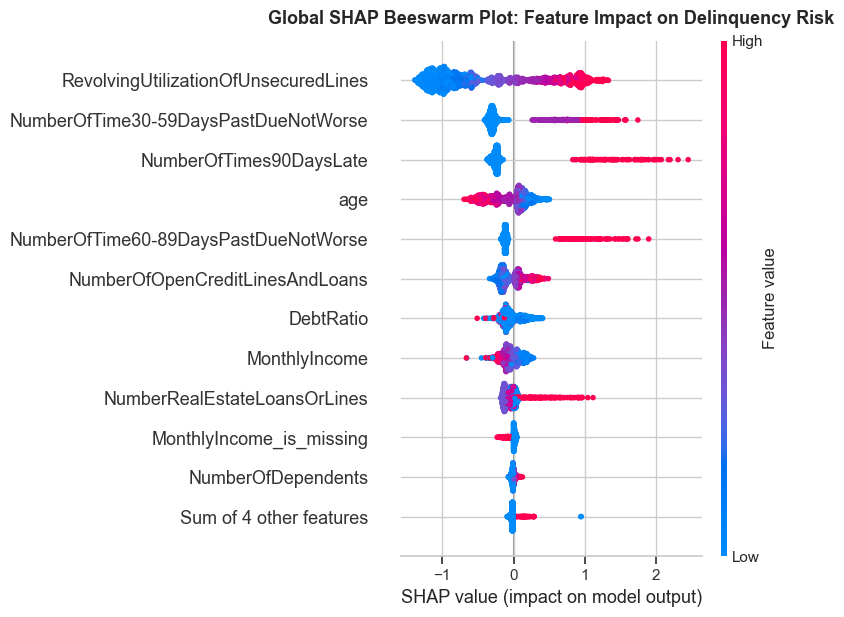

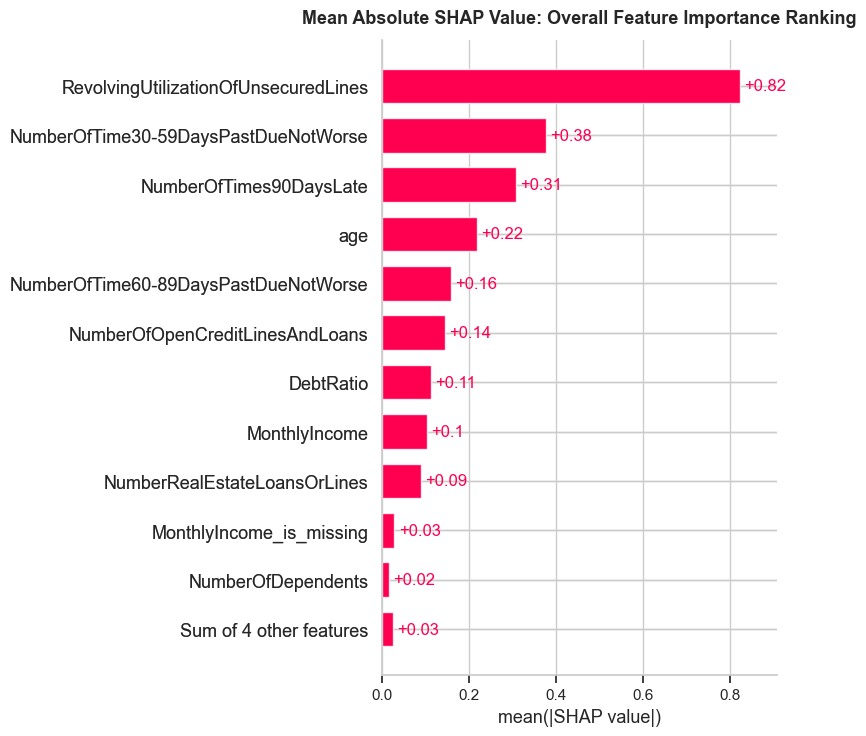

<Figure size 900x500 with 0 Axes>

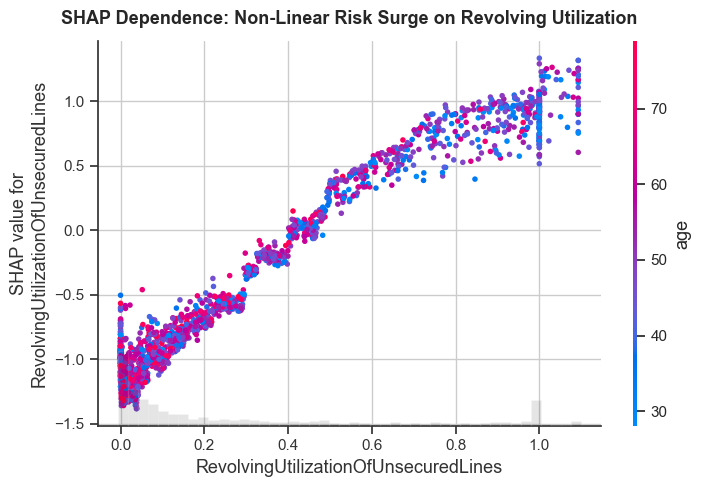

In [8]:
# Compute SHAP Values on a representative sample of test records
SAMPLE_SIZE = 2000
X_test_sample = X_test.iloc[:SAMPLE_SIZE]

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer(X_test_sample)

print(f"SHAP TreeExplainer computed on {SAMPLE_SIZE:,} holdout validation records.")

# Figure 1: Global Summary Beeswarm Plot
plt.figure(figsize=(10, 6))
shap.plots.beeswarm(shap_values, max_display=12, show=False)
plt.title('Global SHAP Beeswarm Plot: Feature Impact on Delinquency Risk', fontweight='bold', fontsize=13, pad=12)
plt.tight_layout()
plt.show()

# Figure 2: Mean Absolute SHAP Value (Global Ranking)
plt.figure(figsize=(10, 5))
shap.plots.bar(shap_values, max_display=12, show=False)
plt.title('Mean Absolute SHAP Value: Overall Feature Importance Ranking', fontweight='bold', fontsize=13, pad=12)
plt.tight_layout()
plt.show()

# Figure 3: SHAP Dependence Plot for Revolving Utilization
plt.figure(figsize=(9, 5))
shap.plots.scatter(shap_values[:, 'RevolvingUtilizationOfUnsecuredLines'], color=shap_values[:, 'age'], show=False)
plt.title('SHAP Dependence: Non-Linear Risk Surge on Revolving Utilization', fontweight='bold', fontsize=13, pad=12)
plt.tight_layout()
plt.show()


---
## 8. 🛡️ Regulatory Compliance: Local Waterfall Plots & Adverse Action Notices

Under the **Equal Credit Opportunity Act (ECOA)** and the **Fair Credit Reporting Act (FCRA)**, whenever an applicant is declined credit, the lending institution is legally required to furnish an **Adverse Action Notice** citing the **top key contributing factors**.

We demonstrate local explainability for two contrasting borrower profiles:
* **Case Study A (Approved Applicant)**: Prime low-risk borrower ($P < 2.0\%$).
* **Case Study B (Declined Applicant)**: Distressed borrower ($P > 60.0\%$) with automated extraction of the top 3 adverse action factors.


Case Study A (Approved Profile #357): Default Prob = 3.10%
Case Study B (Declined Profile #773): Default Prob = 97.24%


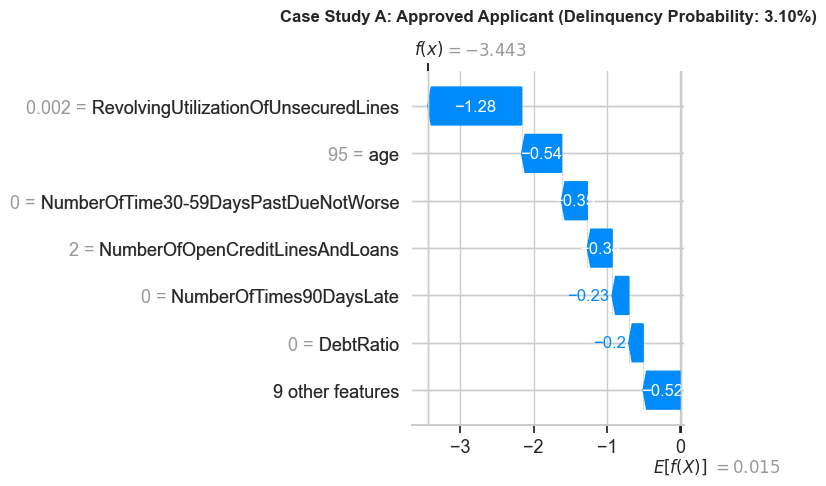

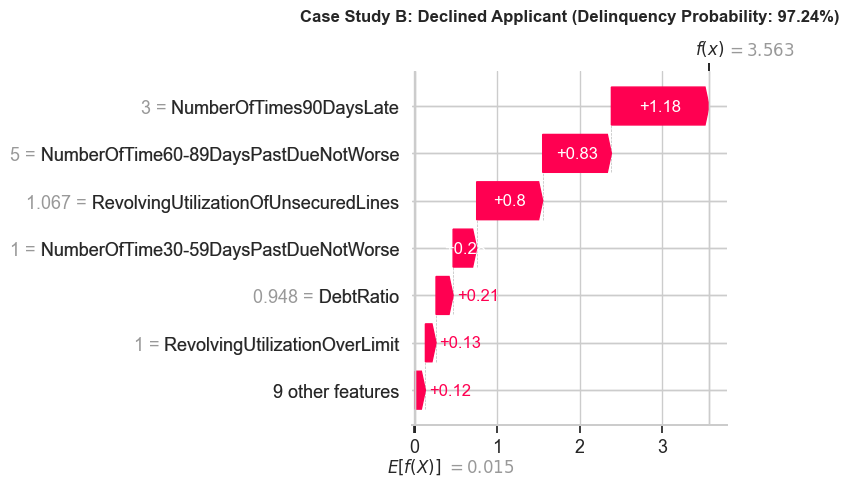

FORMAL ADVERSE ACTION NOTICE REASONS (REGULATORY AUDIT TRAIL):
1. NumberOfTimes90DaysLate (Current Value: 3.00) -> SHAP Contribution: +1.180
2. NumberOfTime60-89DaysPastDueNotWorse (Current Value: 5.00) -> SHAP Contribution: +0.830
3. RevolvingUtilizationOfUnsecuredLines (Current Value: 1.07) -> SHAP Contribution: +0.797


In [9]:
# Identify one low-risk and one high-risk applicant from the test holdout
sample_preds = y_prob_xgb[:SAMPLE_SIZE]

approved_idx = int(np.argmin(sample_preds))       # Lowest default probability
declined_idx = int(np.argmax(sample_preds))       # Highest default probability

print(f"Case Study A (Approved Profile #{approved_idx}): Default Prob = {sample_preds[approved_idx]:.2%}")
print(f"Case Study B (Declined Profile #{declined_idx}): Default Prob = {sample_preds[declined_idx]:.2%}")

# Waterfall Plot for Approved Applicant
plt.figure(figsize=(9, 4.5))
shap.plots.waterfall(shap_values[approved_idx], max_display=7, show=False)
plt.title(f'Case Study A: Approved Applicant (Delinquency Probability: {sample_preds[approved_idx]:.2%})', fontweight='bold', fontsize=12, pad=12)
plt.tight_layout()
plt.show()

# Waterfall Plot for Declined Applicant
plt.figure(figsize=(9, 4.5))
shap.plots.waterfall(shap_values[declined_idx], max_display=7, show=False)
plt.title(f'Case Study B: Declined Applicant (Delinquency Probability: {sample_preds[declined_idx]:.2%})', fontweight='bold', fontsize=12, pad=12)
plt.tight_layout()
plt.show()

# Automated Adverse Action Notice Extraction
declined_shap_contrib = pd.Series(shap_values.values[declined_idx], index=FEATURES).sort_values(ascending=False)
top_adverse_factors = declined_shap_contrib.head(3)

print("="*65)
print("FORMAL ADVERSE ACTION NOTICE REASONS (REGULATORY AUDIT TRAIL):")
for rank, (feat, val) in enumerate(top_adverse_factors.items(), start=1):
    raw_val = X_test_sample.iloc[declined_idx][feat]
    print(f"{rank}. {feat} (Current Value: {raw_val:,.2f}) -> SHAP Contribution: +{val:.3f}")
print("="*65)


---
## 9. 💾 Model Serialization & Day 4 Bridge

To power our Day 4 **Streamlit Interactive Underwriting Simulator Dashboard**, we serialize the champion model along with its operational metadata:
1. `models/best_credit_model.joblib`: The trained XGBoost scoring engine.
2. `models/scaler.joblib`: The fitted feature scaler.
3. `models/model_metadata.json`: Operational hyperparameters, optimal decision threshold, performance benchmarks, and feature schemas.


In [10]:
# Ensure target directory exists
os.makedirs('../models', exist_ok=True)

# 1. Export Models
model_path = '../models/best_credit_model.joblib'
scaler_path = '../models/scaler.joblib'

joblib.dump(xgb_model, model_path)
joblib.dump(scaler, scaler_path)

# 2. Export Metadata
metadata = {
    'project_name': 'CreditRiskAI Delinquency Predictor',
    'author': 'Ganendra Pradipa',
    'champion_model': 'XGBoost Classifier',
    'champion_params': {
        'n_estimators': 120,
        'max_depth': 5,
        'learning_rate': 0.05,
        'scale_pos_weight': round(scale_pos_weight_value, 2)
    },
    'performance_metrics': {
        'roc_auc': round(roc_auc_score(y_test, y_prob_xgb), 4),
        'pr_auc': round(average_precision_score(y_test, y_prob_xgb), 4),
        'ks_statistic_pct': round(max_ks_val * 100, 2),
        'gini_coefficient': round(2 * roc_auc_score(y_test, y_prob_xgb) - 1, 4),
        'brier_score': round(brier_score_loss(y_test, y_prob_xgb), 4)
    },
    'operational_policy': {
        'cost_optimal_threshold': round(optimal_row['threshold'], 2),
        'expected_approval_rate_pct': round(optimal_row['approval_rate'] * 100, 2),
        'expected_default_capture_pct': round(optimal_row['recall'] * 100, 2),
        'cost_fn_usd': COST_FN,
        'cost_fp_usd': COST_FP
    },
    'feature_schema': FEATURES
}

metadata_path = '../models/model_metadata.json'
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=4)

print("="*60)
print("SUCCESSFULLY EXPORTED PRODUCTION MODEL ARTIFACTS:")
print(f"• Model File   : {model_path} ({os.path.getsize(model_path) / 1024:.1f} KB)")
print(f"• Scaler File  : {scaler_path} ({os.path.getsize(scaler_path) / 1024:.1f} KB)")
print(f"• Metadata File: {metadata_path} ({os.path.getsize(metadata_path) / 1024:.1f} KB)")
print("="*60)


SUCCESSFULLY EXPORTED PRODUCTION MODEL ARTIFACTS:
• Model File   : ../models/best_credit_model.joblib (323.2 KB)
• Scaler File  : ../models/scaler.joblib (1.5 KB)
• Metadata File: ../models/model_metadata.json (1.3 KB)
